## Inteligência Artificial - 2025/2026.  
### Trabalho Prático: Estratégias de Pesquisa Adversarial e Árvores de Decisão - MCTS e ID3.  
### PL3 - **Elementos**: **Amanda Carneiro Lucas** (202400455), **Rafael Trivelatto** (202408221) e **Simão Filipe de Sousa Martins** (202404938)

## 1) Introdução  
&nbsp;Este trabalho prático tem como intuito colocar em prática os conhecimentos adquiridos na cadeira **(CC2006) - Inteligência Artificial**, sobretudo as noções sobre **Estratégias de Pesquisa Adversarial** e  **Árvores de Decisão**, nosso foco é aplicar o algoritmo **MCTS - Monte Carlos Tree Search** ao jogo proposto em assignment, para assim analisar e entender como eventuais mudanças no algoritmo podem impactar em seu funcionamento e performance, para além disso, usaremos o algoritmo **ID3 - Iteratitive Dichotomizer 3** para aprender uma árvore de decisão capaz de classificar novos exemplos.

## 2) PopOut - O jogo

### 2.1) Introdução e Regras

&nbsp;O desafio consiste em implementar o jogo **PopOut** - que é uma variante do famoso jogo **Connect-4**. O **PopOut** funciona quase que por completo como o jogo conhecido, porém, para além das regras e mecânicas conhecidas no **Connect-4** também é suposto que um jogador consiga dar **pop out** numa coluna, isto é, remover a ultima peça de tal coloca, assim tornando mais complexo e com uma gama maior de jogas disponíveis por rodada.   

<div align="center">
  <img src="img/Screenshot 2026-05-13 155134.png" width="500px">
  <br>
  <sup><b>Figura 1:</b> Retirada do Assignment - IA_2526_Trab.</sup>
</div> 

&nbsp;Além da dinâmica de **PopOut**, o jogo se difere do **Connect-4** através de 3 principais regras:  
- 1) Para lidar com 'four-in-rows' que é a condição de terminalidade, simultâneos, se uma jogada **pop out** criar 'four-in-rows' para ambos os jogadores, aquele que executou o **pop out** é declarado como o vencedor da partida.
- 2) Para lidar com o tabuleiro cheio, o jogador responsável pelo próximo movimento pode optar por dar **pop out** em alguma coluna possível ou finalizar a partida como o resultado final de **empate**.
- 3) Para lidar com repetições, se um estado de jogo se repetir **3 vezes**, qualquer um dos jogadores tem  o direito de declarar **empate** e finalizar a partida.

&nbsp;Ou seja, trabalhamos aqui com um **'Jogo com Oponentes'** também apresentado como um **problema de pesquisa adversarial** que ocorre em ambientes competitivos onde dois ou mais agentes têm objetivos conflitantes. Diferente de uma busca comum, o estado futuro do "mundo" não depende apenas das ações do agente, mas também das contra-atitudes de um oponente que tenta ativamente minimizar o sucesso do agente. O **PopOut** é, por natureza, um problema que exige Informed Search (Busca Informada), nesse tipo de busca se utiliza conhecimento específico do domínio para guiar a busca de forma mais eficiente através de uma função heurística **$h(n)$** . No **PopOut** essa é a abordagem necessária e será aplicada através do algoritmo **MCTS**, ele "aprende" a heurística através de simulações (playouts), em vez de usar apenas uma fórmula matemática fixa de **$h(n)$**, como o espaço de estados é vasto, o algoritmo usa uma heurística para avaliar o tabuleiro (ex: dar pontos para "3 peças em linha" ou "controle do centro") e decidir a melhor jogada sem precisar calcular todas as possibilidades até o fim da partida.  

### 2.2) Definindo o PopOut como um Problema de Pesquisa Adversarial  

&nbsp;Podemos então definir tal situação como um **problema de pesquisa adversarial** em um ambiente de **Soma Zero (Zero-Sum)**, dizemos que um jogo é de soma zero quando o ganho de um jogador é matematicamente igual à perda do outro. Não há possibilidade de ambos ganharem ou ambos perderem (exceto no caso de empate técnico, onde a utilidade é zero para ambos). No **PopOut** se o jogador Branco vence (+1), o jogador Vermelho necessariamente perde (-1). A soma das utilidades é sempre zero: $(+1) + (-1) = 0$.Também podemos dizer que estamos em um ambiente com **Informação Perfeita (Perfect Information)**, um jogo possui informação perfeita quando todos os jogadores têm acesso a todos os dados sobre o estado do jogo a qualquer momento. Não existem elementos ocultos (como cartas na mão de um adversário) ou eventos aleatórios desconhecidos (como neblina de guerra). 

&nbsp;Um **Jogo** pode ser definido como um tipo de **problema de pesquisa** com os seguintes componentes: **estado inicial, função de sucessores, condição de terminalidade, função de utilidade e limite de profundidade (caso aplicável)**. Também contamos com a **Dinâmica dos Jogadores: MIN e MAX**, o problema é modelado com dois agentes competitivos:
- **MAX** (Geralmente o primeiro a jogar): Busca maximizar o valor da utilidade final. No nosso **PopOut** é representado por **'X'**.
- **MIN** (Oponente): Busca minimizar a utilidade de MAX (o que equivale a maximizar a sua própria vantagem). No nosso **PopOut** é representado por **'O'**.

&nbsp;Para modelar o **PopOut** sob a ótica da Inteligência Artificial definimos estes elementos da seguinte forma: 
- **Estado Inicial (Initial State)**: Configuração do tabuleiro e indicação de quem joga o turno. No **PopOut** isso é representado pelo tabuleiro vazio ($7 \times 6$) e a indicação de que o jogador MAX (no caso 'X') inicia a partida.
- **Função de Sucessores (Function to generate successors)**: Retorna uma lista dos sucessores da jogada atual. No **PopOut** gera a lista de estados possíveis a partir de movimentos de Drop (colocar peça) ou PopOut (remover da base, se a peça for da cor do jogador atual).
- **Condição de Terminalidade (Termination Test)**: Verifica se o estado atual é final. No **PopOut** verifica se um jogador conectou 4 peças ou se o tabuleiro está cheio (empate).
- **Função de Utilidade (Utility Function)**: Retorna o valor numérico do jogo (ex: vitória (+1, inf), empate (0), derrota (-1, − inf)), No **PopOut** retorna valor numérico do jogo no estado terminal, ex: Vitória de **'X'** (MAX), Vitória do **'O'** (MIN), empate entre **'X' e 'O'** e etc.
- **Limite de Profundidade (Depth Limit)**: Usado em ocasiões onde o **Espaço de Busca (Search Space)** é suficientemente vasto. No **PopOut** Como o espaço de busca é vasto e gerado automaticamente, utiliza-se um limite de profundidade aliado ao **MCTS** e/ou heurísticas para avaliar estados não terminais.


## 3) Interface do Jogo

### 3.1) Classe Tabuleiro (Board)
&nbsp;Para implementar o jogo descrito acima, usaremos a linguagem Python (v 3.14.3) com a ajuda da biblioteca NumPy - usada para cálculos numéricos científicos com alta precisão. O primeiro passo é definir uma classe (objeto) que define o tabuleiro, as regras do jogo, e define as ações necessárias - como checkar se o jogo finalizou, se a jogada é possível, efetivar tal jogada e a função que irá imprimir o tabuleiro para visualização. A classe a seguir define isso:

In [3]:
import numpy as np

class Board: #cria uma classe chamada 'Board'

    def __init__(self): #função que inicia o tabuleiro
        self.board = np.full((6, 7), ' ', dtype=str) #cria um tabuleiro de 7 colunas e 6 linhas
        self.empty = 42 #define se está vazio - são 42 slots (7x6)
        self.record = dict() #guarda estado num dicionario
        self.record[repr(self)] = 1 #marca que o estado ocorreu
        self.state = ' ' 

    def isLegal(self, isX: bool, move: tuple[int, int]): #função que garante que as jogadas são validas
        r, c = move[0], move[1] - 1
        if r == 0:
            return ((isX and self.board[5, c] == 'X') or (not isX and self.board[5, c] == 'O'))
        if r == 1:
            return self.board[6 - r, c] == ' '
        return (self.board[7 - r, c] != ' ' and self.board[6 - r, c] == ' ')
    
    def playMove(self, icon: str, move: tuple[int, int]): #função que efetiva jogada (se valida)
        if move == "tie":
            self.state = "Game ends on a tie!"
            return
        r, c = move[0], move[1] - 1
        if r == 0:
            self.board[1:, c] = self.board[:-1, c]
            self.board[0, c] = ' '
            self.empty += 1
        else:
            self.board[6 - r, c] = icon
            self.empty -= 1
        current_state = repr(self)
        if current_state in self.record:
            if self.record[current_state] == 2:
                self.state = "Game ends on a tie!"
            else:
                self.record[current_state] += 1
        else:
            self.record[current_state] = 1  
        self.checkWin('O' if icon == 'X' else 'X')
        self.checkWin(icon)

    def checkWin(self, icon: str): #função que checka se houve vitória
        b = (self.board == icon)
        if np.any(b[:, :-3] & b[:, 1:-2] & b[:, 2:-1] & b[:, 3:]):
            self.state = f"Game ends on {icon}'s win!"
            return
        if np.any(b[:-3, :] & b[1:-2, :] & b[2:-1, :] & b[3:, :]):
            self.state = f"Game ends on {icon}'s win!"
            return
        if np.any(b[:-3, :-3] & b[1:-2, 1:-2] & b[2:-1, 2:-1] & b[3:, 3:]):
            self.state = f"Game ends on {icon}'s win!"
            return
        if np.any(b[3:, :-3] & b[2:-1, 1:-2] & b[1:-2, 2:-1] & b[:-3, 3:]):
            self.state = f"Game ends on {icon}'s win!"
            return

    def __str__(self): #função que imprime estado
        printer = "  -----------------------------\n"
        for i in range(6):
            printer += f"{6 - i} |"
            for j in range(7):
                current = self.board[i, j]
                if current in ('X', 'O'):
                    printer += f" {current} |"
                else:
                    printer += "   |"
            printer += "\n  -----------------------------\n"
        printer += "    1   2   3   4   5   6   7"
        return printer
    
    def __repr__(self): #função que efetiva estado
        return "".join(self.board.ravel())

### 3.2) Classe Jogador (Player)
&nbsp;Para além disso, precisamos também de uma classe que define o jogador e suas possíveis jogadas. A classe a seguir implementa tal: 

In [4]:
class Player: #cria uma classe chamada 'Player'
    def __init__(self, isX: bool): #inicia um player - 'X' = MAX
        self.isX = isX

    def getPossibleMoves(self, board):
        moves = []
        
        # 1. Verifica Pop Moves (Sempre avalia a linha inferior)
        for i in range(1, 8):
            if (board.board[5][i - 1] == 'X' and self.isX) or (board.board[5][i - 1] == 'O' and not self.isX):
                moves.append((0, i))
                
        # 2. Verifica Drop Moves (Apenas se houver espaço vazio)
        if board.empty > 0:
            for i in range(1, 8):
                for j in range(1, 7):
                    if board.board[6 - j][i - 1] == ' ':
                        moves.append((j, i))
                        break
        
        # 3. Regra do Tabuleiro Cheio
        # Se encheu, o jogador TEM a opção de declarar empate,
        # concorrendo com as opções de Pop (se ele tiver peças na base)
        if board.empty == 0:
            moves.append("tie") 
            
        # Tratamento de segurança extremo: se não tem espaço e não tem pop
        if len(moves) == 0:
            moves.append("tie")
            
        return moves

    def turn(self, board, printer=True): 
        
        """ Essa função está aqui apenas de assinatura, 
            a sua implementação vai variar dependendo da subclasse que vem a seguir"""

        raise NotImplementedError("A subclasse deve implementar o método turn!")

    def __str__(self): #imprime o player
        return 'X' if self.isX else 'O'

### 3.3) Subclasse Jogador Humano (HumanPlayer)
Definimos uma subclasse (da classe 'Player') que representa o 'Jogador Humano':

In [5]:
class HumanPlayer(Player):
    def turn(self, board, printer=True):
        if printer:
            print(f"\n{self}'s turn")
            # Mostramos os movimentos possíveis para ajudar o humano
            #print(f"Possíveis tuplas (backend): {self.getPossibleMoves(board)}")
            
        while True:
            try:
                col = int(input("Escolha a coluna (1-7): "))
                tipo = input("Deseja (D)rop ou (P)op out? ").strip().upper()
                
                if tipo == 'P':
                    # No seu backend, PopOut é sempre linha 0
                    move = (0, col)
                elif tipo == 'D':
                    # Para o Drop, precisamos descobrir qual é a linha livre 
                    # usando a lógica que você já tem no getPossibleMoves
                    possiveis = self.getPossibleMoves(board)
                    # Filtra os movimentos que são Drop (linha > 0) para a coluna escolhida
                    move_encontrado = [m for m in possiveis if m[0] > 0 and m[1] == col]
                    
                    if move_encontrado:
                        move = move_encontrado[0]
                    else:
                        print("Coluna cheia! Não é possível dar Drop aqui.")
                        continue
                else:
                    print("Tipo inválido! Digite 'D' para Drop ou 'P' para Pop.")
                    continue

                # Agora testamos se essa tupla gerada é legal
                if board.isLegal(self.isX, move):
                    board.playMove(str(self), move)
                    return move
                else:
                    print(f"A jogada {tipo} na coluna {col} não é permitida pelas regras.")
            
            except ValueError:
                print("Entrada inválida! Digite apenas números para a coluna.")

&nbsp;Tal qual definido no escopo do projeto, vamos desenvolver 3 modos do jogo **PopOut**, estes são:  
1) Humano vs Humano
2) Humano vs Computador (usamos **MCTS** como bot)
3) Computador vs Computador (dois **MCTS** sendo adversários)

&nbsp;Começamos então utilizando das classes definidas acima para implementar a primeira opção de jogo:

### 3.4) Jogando o jogo **Humano vs Humano**

In [6]:
'''print("--- Humano Vs Humano ---")
playerX = HumanPlayer(isX=True)
playerO = HumanPlayer(isX=False)
board = Board()

print(board)
while board.state == ' ':
    playerX.turn(board)
    print(board)
    if board.state != ' ':
        break
    playerO.turn(board)
    print(board)
print(board.state)'''

'print("--- Humano Vs Humano ---")\nplayerX = HumanPlayer(isX=True)\nplayerO = HumanPlayer(isX=False)\nboard = Board()\n\nprint(board)\nwhile board.state == \' \':\n    playerX.turn(board)\n    print(board)\n    if board.state != \' \':\n        break\n    playerO.turn(board)\n    print(board)\nprint(board.state)'

&nbsp;Acima conseguimos então, de maneira completa, jogar o **PopOut** no modo **Humano vs Humano**. Para implementar os dois últimos modos de jogo, utilizaremos o algoritmo **MCTS** como 'Computador', sendo assim, primeiro vamos entender como tal algoritmo funciona.

## 4) Trabalho para desenvolver

&nbsp;O objetivo desse projeto é implementar o algoritmo **MCTS - Monte Carlo Tree Search** (e algumas variações do mesmo), e também o algoritmo **ID3 - Iteratitive Dichotomizer 3** para gerar **Árvores de Decisão** para os datasets analisados: Iris Dataset (para treino e análise) e PopOut Dataset (gerado a partir de simulações do próprio jogo).

### 4.1) Monte Carlo Tree Search:  

&nbsp;**MCTS - Monte Carlo Tree Search** é um algoritmo de **pesquisa adversarial** que leva em consideração que um adversário pode trocar o sistema de estados em passos subsequentes, esse algoritmo de busca não tenta calcular todas as possibilidades de forma exata, mas sim usa estatísticas e simulações para "adivinhar" quais caminhos são mais promissores.   
&nbsp;Para tal, o **MCTS** constrói uma **árvore estatística** que é parcial, diferente da árvore de jogo completa - que contém todos os bilhões de movimentos possíveis. Essa **árvore** só cria nós para as jogadas que o **MCTS** realmente explora. Se uma jogada do **PopOut** parece muito ruim logo de cara, o **MCTS** pode nem chegar a criar os nós filhos dessa jogada na memória. Dessa forma **árvore estatística** guia a IA para 'olhar única e/ou majoritariamente para os **nós mais interessantes** na árvore de jogo', servindo assim como um mapa de calor. Os valores dos **nós** são determinados através de simulações.  

&nbsp;Os **nós** dessa árvore armazenam duas informações cruciais:
- 1) $U$: O numero de jogadas que levam a vitória e passam por esse nó (estado).  
- 2) $N$: Quantas vezes esse estado foi visitado.

#### 4.1.1) Nó do MCTS  

&nbsp;O ciclo do **MCTS** segue 4 passos: 

<center>

#### 1. **Seleção (Selection)**

</center>

O algoritmo começa na raiz (estado atual do tabuleiro) e navega pela **árvore estatística** já existente. Então o algoritmo usa a fórmula **UCB1 (Upper Confidence Bound applied to Trees)** para decidir qual **nó filho** vai visitar. Tal fórmula pode ser representada por:
  <div align="center">
    <img src="img/Screenshot 2026-05-13 175814.png" width="500px">
    <br>
    <sup><b>Figura 3:</b> Retirada do slide - IA 2526 Class 4 MCTS.</sup>
  </div>  


  Isso contém as seguintes informações: 
  - **$U(n)$**: Número de vitórias para o nó $n$;
  - **$N(PARENT(n))$**: Número de vezes que o nó pai de $n$ foi visitado;
  - **$N(n)$**: Número de vezes que o nó $n$ foi visitado;
  - **Explotação (Exploitation)**: Primeira parte da soma (esquerda) - $\frac{U(n)}{N(n)}$
    - Tem enfase na recompensa (alta para jogadas com alta média de vitória), implica uma busca mais guiada. Assim prioriza caminhos que já provaram ser bons (onde ganhamos muitas vezes).
  - **Exploração (Exploration)**: Segunda parte da soma (direita) - $C \times\frac{\sqrt{\ln N(PARENT(n))}}{N(n)}$
    - Reforça a exploração de nós menos visitados (alta para jogadas com poucas simulações). 
    - Ao olhar para o número de vezes que o nó pai de $n$ foi visitado, vemos que este número cresce no numerador, se não visitarmos o nó $n$ (que está no denominador), o valor total deste termo aumenta.O $\ln$ (Logaritmo natural) faz com que o valor de exploração cresça devagar, impedindo que o algoritmo foque apenas no desconhecido.
  - **$C$**: Constante que equilibra Explotação vs Exploração. Um $C$ alto faz a IA testar mais, um $C$ baixo faz a IA ser mais conservadora e priorizar jogadas já conhecidas. É um parâmetro flutuante, geralmente se usa **$\sqrt{2}$**, testaremos diferentes $C$ para analisar seu impacto na prática.  

<div class="alert alert-block alert-info">

-**Exemplo aplicado (PopOut)**: Supomos que na rodada atual, contamos com duas opções de movimentos:
- 1) **Drop na Coluna 1**: Foi visitado 100 vezes e venceu 80. O termo de explotação é alto ($0.8$).
- 2) **PopOut na coluna 4**: Foi visitado apenas 2 vezes e venceu 1. O termo de explotação é médio ($0.5$), mas o termo de exploração será gigantesco porque ele foi muito pouco testado comparado ao pai.
- **Resultado**: O UCB1 fará o algoritmo escolher o PopOut algumas vezes para garantir que aquela jogada de apenas 2 visitas não é, na verdade, uma jogada brilhante que foi ignorada. À medida que o número de visitas ($N(n)$) aumenta, o termo de exploração diminui, e a IA passa a confiar mais na média de vitórias real. 

</div>

<center>

#### 2. **Expansão (Expansion)**

</center>

Uma vez que o algoritmo selecionou um nó que pode ser expandido,isso é, um nó que **não é estado terminal** e ainda **não foi expandido**, ele escolhe uma das ações disponíveis (no caso Drop ou PopOut) que ainda não foi explorada e **cria um novo nó filho na árvore**, então este novo nó representa o **estado do tabuleiro** após essa jogada.  

<center>

#### 3. **Simulação (Simulation/Playout)**

</center>

A partir do novo nó criado, o algoritmo realiza uma **partida completa e rápida contra si mesmo**. As jogadas são feitas de forma aleatória, nessa etapa não há construção de árvore, o algoritmo apenas simula o jogo até que alguém vença ou o tabuleiro encha. Aqui o objetivo é apenas 'ver quem ganha' se seguirmos por tal caminho.

<center>

#### 4. **Retropropagação (Backpropagation)**

</center>

Após o final da simulação, temos um **resultado** (Vitória, Derrota, ou Empate). Esse resultado é enviado de volta para cima na árvore. De tal forma que:
  - Todos os nós que foram percorridos no passo **1) Seleção**, e no nó escolhido no passo **2) Expansão** tem suas estatísticas atualizadas.
  - Se o jogador MAX (no caso 'X') venceu, adicionamos +1 ao contator de vitórias desses nós, e para todos o contator de visitas aumenta em +1.


<div align="center">
  <img src="img/Screenshot 2026-05-13 174535.png" width="500px">
  <br>
  <sup><b>Figura 2:</b> Retirada do slide - IA 2526 Class 4 MCTS.</sup>
</div>   
 
&nbsp;Depois de repetir os 4 passos por X vezes (10.000 no caso), então o **MCTS** pode finalmente mover a peça no tabuleiro real, o algoritmo  **mais visitado** ($N$ mais alto), pois ele representa a jogada que o algoritmo explorou exaustivamente e validou como a mais segura.



### Implementação em Python

&nbsp;Agora que vimos como o MCTS funciona na teoria podemos finalmente implementar funções correspondentes aos 4 passos supracitados, para além disso também definimos algumas funções auxiliares importantes para o bom funcionamento do algoritmo nesse projeto. São elas:
- **is_fully_expanded**: Usada no passo de Seleção. Avisa que não há mais jogadas novas para testas.
- **is_terminal**: Usada caso o jogo já tenha acabado.
- **to_bitboard**: Prepara o tabuleiro para o teste rápido.
- **get_bit_move**: Lista jogadas aleatórias possíveis em bits.
- **apply_bit_pop**:Executa a jogada sorteada nos bits.
- **check_bit_win**: Verifica se a partida aleatória acabou em vitória.


In [7]:
import copy
import random

class MCTSNode:
    def __init__(self, board, move=None, parent=None, constant=1.41, isX=True):
        self.board = copy.deepcopy(board)
        self.move = move
        self.parent = parent
        self.constant = constant
        self.isX = isX
        self.children = []
        self.wins = 0
        self.visits = 0
        self.untriedMoves = MCTSPlayer(isX).getPossibleMoves(self.board)

    def ucb1(self, child):
        """Calcula o valor UCB1 para um filho específico."""
        exploitation = child.wins / child.visits
        exploration = self.constant * np.sqrt(np.log(self.visits) / child.visits)
        return exploitation + exploration

    def best_child(self):
        """Retorna o filho com o maior valor UCB1."""
        return max(self.children, key=self.ucb1)

    def select(self):
        """
        Navega pela árvore usando UCB1. 
        Este método é chamado na fase 1 do MCTS.
        """
        return self.best_child()


    def expand(self):
        move = self.untriedMoves.pop()
        next_board = copy.deepcopy(self.board)
        icon = 'X' if self.isX else 'O'
        next_board.playMove(icon, move)
        # Ao criar o filho, passamos a mesma constante de exploração
        child_node = MCTSNode(next_board, move=move, parent=self, constant=self.constant, isX=not self.isX)
        self.children.append(child_node)
        return child_node
    
    def update(self, result):
        self.visits += 1
        if not self.isX: 
            self.wins += result
        else:
            self.wins += (1.0 - result)
        if self.parent:
            self.parent.update(result)

    def is_fully_expanded(self):
        return len(self.untriedMoves) == 0

    def is_terminal(self):
        return self.board.state != ' '

    def rollout(self):
        board_x, board_o = self.to_bitboard(self.board.board)
        current_x_turn = self.isX
        all_cells_mask = 0b111111_111111_111111_111111_111111_111111_111111
        while True:
            moves = self.get_bit_moves(board_x, board_o, current_x_turn)
            if not moves: return 0.5
            move_bit, is_pop = random.choice(moves)
            if is_pop:
                board_x, board_o = self.apply_bit_pop(board_x, board_o, move_bit)
            else:
                if current_x_turn: board_x |= move_bit
                else: board_o |= move_bit
            
            x_wins = self.check_bit_win(board_x)
            o_wins = self.check_bit_win(board_o)
            
            if x_wins and o_wins: return 0.5
            if x_wins: return 1.0
            if o_wins: return 0.0
            if (board_x | board_o) == all_cells_mask: return 0.5
            current_x_turn = not current_x_turn

    def to_bitboard(self, grid):
        board_x = 0
        board_o = 0
        for c in range(7):
            for r in range(6):
                shift = c * 7 + r
                if grid[5-r, c] == 'X':
                    board_x |= (1 << shift)
                elif grid[5-r, c] == 'O':
                    board_o |= (1 << shift)
        return board_x, board_o
    
    def get_bit_moves(self, board_x, board_o, isX):
        moves = []
        occupied = board_x | board_o
        for c in range(7):
            bottom_bit = 1 << (c * 7)
            if isX:
                if board_x & bottom_bit: moves.append((bottom_bit, True))
            else:
                if board_o & bottom_bit: moves.append((bottom_bit, True))
            top_bit = 1 << (c * 7 + 5)
            if not (occupied & top_bit):
                column_mask = 0b111111 << (c * 7)
                empty_in_col = (~occupied) & column_mask
                lowest_empty = empty_in_col & -empty_in_col
                moves.append((lowest_empty, False))
        return moves
    
    def apply_bit_pop(self, board_x, board_o, move_bit):
        col_idx = 0
        temp_bit = move_bit
        while temp_bit > 0b111111:
            temp_bit >>= 7
            col_idx += 1
        col_mask = 0b111111 << (col_idx * 7)
        bits_above_mask = (col_mask ^ move_bit) & (-(move_bit << 1))
        new_x = (board_x & ~col_mask) | ((board_x & bits_above_mask) >> 1)
        new_o = (board_o & ~col_mask) | ((board_o & bits_above_mask) >> 1)
        return new_x, new_o

    def check_bit_win(self, bitboard):
        m = bitboard & (bitboard >> 7)
        if m & (m >> 14): return True
        m = bitboard & (bitboard >> 1)
        if m & (m >> 2): return True
        m = bitboard & (bitboard >> 6)
        if m & (m >> 12): return True
        m = bitboard & (bitboard >> 8)
        if m & (m >> 16): return True
        return False

#### 4.1.2) Subclasse de Jogador MCTS (MCTSPlayer)
&nbsp;Definimos então uma subclasse do Player para representar o **MCTS** como um jogador de **PopOut**:


In [8]:
class MCTSPlayer(Player):
    def turn(self, board, printer=True):
        if printer:
            print(f"{self}'s turn (MCTS pensando...)")
        
        move = mcts_base(board, self.isX, 10000)
        
        board.playMove(str(self), move[0])
        return move[1]

#### 4.1.3) MCTS - Modo Base  
&nbsp;Agora temos o necessário para implementar o **MCTS** para jogar nosso jogo **PopOut**, para começar, trabalhamos com o **MCTS** clássico, que usa $C = \sqrt{2}$ e escolhe o melhor nó através da função com calculo do UCB1:

In [9]:
def mcts_base(rootBoard, isX: bool, iterations=10000, constant=1.41):
    
    # variavel responsavel por guardar o estado atual
    rootNode = MCTSNode(rootBoard, None, None, constant, isX)

    for _ in range(iterations):                   
        node = rootNode

        # Seleção
        while node.is_fully_expanded() and not node.is_terminal():
            node = node.select()

        # Expansão
        if not node.is_terminal():
            node = node.expand()
        
        # Simulação
        result = node.rollout()

        # BackPropagation
        node.update(result)

    best_move_node = max(rootNode.children, key=lambda c: c.visits)
    
    return best_move_node.move, best_move_node.move

#### 4.1.4) Humano vs Computador (usando **MCTS** Clássico como bot)

In [10]:
''' humano vs mcts
import random 
print("--- Humano Vs MCTS ---")
if random.randint(0, 1) == 0:
    playerX = HumanPlayer(isX=True)
    playerO = MCTSPlayer(isX=False)
else:
    playerX = MCTSPlayer(isX=True)
    playerO = HumanPlayer(isX=False)

board = Board()
print(board)
while board.state == ' ':
    playerX.turn(board)
    print(board)
    if board.state != ' ':
        break
    playerO.turn(board)
    print(board)
print(board.state)
'''

' humano vs mcts\nimport random \nprint("--- Humano Vs MCTS ---")\nif random.randint(0, 1) == 0:\n    playerX = HumanPlayer(isX=True)\n    playerO = MCTSPlayer(isX=False)\nelse:\n    playerX = MCTSPlayer(isX=True)\n    playerO = HumanPlayer(isX=False)\n\nboard = Board()\nprint(board)\nwhile board.state == \' \':\n    playerX.turn(board)\n    print(board)\n    if board.state != \' \':\n        break\n    playerO.turn(board)\n    print(board)\nprint(board.state)\n'

In [11]:
import math
class MCTSPlayer(Player):
    def __init__(self, isX, name="Bot", config=None):
        super().__init__(isX)
        self.name = name
        # Config padrão: tudo desligado (Clássico)
        self.config = config if config else {
            "bias": False, "fpu": False, "smart": False, "iter": 5000
        }

    def turn(self, board, printer=True):
        if printer: print(f"[{self.name}] ({'X' if self.isX else 'O'}) pensando com config: {self.config}")
        
        # Chama a função mcts_buffed passando as flags da config
        move = mcts_buffed(board, self.isX, 
                           iterations=self.config.get("iter", 5000),
                           bias=self.config["bias"],
                           fpu=self.config["fpu"],
                           smart=self.config["smart"])
        
        board.playMove(str(self), move[0]) 
        return move[1]

In [12]:
def mcts_buffed(rootBoard, isX, iterations, bias, fpu, smart, max_children=None, constant=0.8):
    root = MCTSNodeBuffed(
        rootBoard, 
        isX=isX, 
        constant=constant,
        use_bias=bias, 
        use_fpu=fpu, 
        use_smart_rollout=smart, 
        max_children=max_children
    )
    
    for _ in range(iterations):
        node = root
        
        while node.is_fully_expanded() and not node.is_terminal():
            node = node.select()
            
        if not node.is_terminal():
            node = node.expand()
            
        result = node.rollout()
        node.update(result)
    
    best_child = max(root.children, key=lambda c: c.visits)
    
    # VOLTAMOS PARA O RETORNO DUPLICADO! 
    # Assim o seu MCTSPlayer original funciona perfeitamente sem precisar alterar nada nele.
    return best_child.move, best_child.move

In [13]:
class MCTSNodeBuffed(MCTSNode):
    # O pruning voltou para a assinatura para não dar erro no seu código atual
    def __init__(self, board, move=None, parent=None, constant=0.8, isX=True, 
                 use_bias=False, use_fpu=False, use_smart_rollout=False, max_children=None):
        
        super().__init__(board, move, parent, constant, isX)
        
        self.use_bias = use_bias
        self.use_fpu = use_fpu
        self.use_smart_rollout = use_smart_rollout
        self.max_children = max_children
        
        # O REQUISITO DO PROFESSOR: Limitando o número de filhos avaliados
        if self.max_children and len(self.untriedMoves) > self.max_children:
            self.untriedMoves.sort(key=lambda m: (m == 0, abs(4 - m[1])))
            self.untriedMoves = self.untriedMoves[:self.max_children]

        self.h_value = self.calculate_heuristic() if use_bias else 0

    def select(self):
        # Obriga o nó buffado a usar a matemática nova
        return max(self.children, key=lambda c: self.ucb1(c))

    def calculate_heuristic(self):
        score = 0
        if self.move:
            col = self.move[1]
            if col == 4: score += 0.2
            elif col in [3, 5]: score += 0.1 
        return score

    def ucb1(self, child):
        # TRATAMENTO FPU CORRIGIDO
        if child.visits == 0:
            if self.use_fpu:
                return (self.wins / self.visits) if self.visits > 0 else 0.5
            else:
                return float('inf')

        exploitation = child.wins / child.visits
        exploration = self.constant * math.sqrt(math.log(self.visits) / child.visits)
        
        bias = 0
        if self.use_bias:
            bias = self.h_value / (child.visits + 1)
            
        return exploitation + exploration + bias

    def rollout(self):
        if not self.use_smart_rollout:
            return super().rollout() 
        
        board_x, board_o = self.to_bitboard(self.board.board)
        curr_x = self.isX
        for _ in range(50): 
            moves = self.get_bit_moves(board_x, board_o, curr_x)
            if not moves: break
            
            selected_move = None
            for m_bit, is_pop in moves:
                if not is_pop:
                    tx, to = (board_x | m_bit, board_o) if curr_x else (board_x, board_o | m_bit)
                    if self.check_bit_win(tx if curr_x else to):
                        selected_move = (m_bit, is_pop)
                        break
            
            move_bit, is_pop = selected_move if selected_move else random.choice(moves)
            
            if is_pop: board_x, board_o = self.apply_bit_pop(board_x, board_o, move_bit)
            else:
                if curr_x: board_x |= move_bit
                else: board_o |= move_bit
            
            if self.check_bit_win(board_x): return 1.0
            if self.check_bit_win(board_o): return 0.0
            curr_x = not curr_x
        return 0.5

    def expand(self):
        move = self.untriedMoves.pop()
        next_board = copy.deepcopy(self.board)
        next_board.playMove('X' if self.isX else 'O', move)
        # Repassando o pruning inofensivo
        child = MCTSNodeBuffed(next_board, move, self, self.constant, not self.isX,
                               self.use_bias, self.use_fpu, self.use_smart_rollout, self.max_children)
        self.children.append(child)
        return child

In [14]:
import random 
''' humano vs mctsbuffado
print("\n--- Configuração de Partida: Humano Vs MCTS Buffado ---")

# 1. Definir as heurísticas do Bot de forma atômica
def get_custom_config():
    print("\nConfigure as habilidades do MCTS:")
    return {
        "bias":    input("  > Ativar Progressive Bias? (s/n): ").lower() == 's',
        "fpu":     input("  > Ativar FPU (First Play Urgency)? (s/n): ").lower() == 's',
        "smart":   input("  > Ativar Smart Rollout (Win/Loss Detection)? (s/n): ").lower() == 's',
        "iter":    int(input("  > Número de iterações (ex: 5000): "))
    }

config_do_bot = get_custom_config()

# 2. Sorteio de quem começa (X ou O)
if random.randint(0, 1) == 0:
    print("\n[VOCÊ É O 'X' E COMEÇA!]")
    playerX = HumanPlayer(isX=True)
    playerO = MCTSPlayer(isX=False, name="MCTS_Campeao", config=config_do_bot)
else:
    print("\n[O BOT É O 'X' E COMEÇA!]")
    playerX = MCTSPlayer(isX=True, name="MCTS_Campeao", config=config_do_bot)
    playerO = HumanPlayer(isX=False)

# 3. Execução do Jogo (O loop permanece quase igual, mas usa os players configurados)
board = Board()
print(board)

while board.state == ' ':
    # Turno do Jogador X
    playerX.turn(board)
    print(board)
    if board.state != ' ':
        break
    
    # Turno do Jogador O
    playerO.turn(board)
    print(board)

print("\nFIM DE JOGO!")
print(f"Resultado: {board.state}")
'''

' humano vs mctsbuffado\nprint("\n--- Configuração de Partida: Humano Vs MCTS Buffado ---")\n\n# 1. Definir as heurísticas do Bot de forma atômica\ndef get_custom_config():\n    print("\nConfigure as habilidades do MCTS:")\n    return {\n        "bias":    input("  > Ativar Progressive Bias? (s/n): ").lower() == \'s\',\n        "fpu":     input("  > Ativar FPU (First Play Urgency)? (s/n): ").lower() == \'s\',\n        "smart":   input("  > Ativar Smart Rollout (Win/Loss Detection)? (s/n): ").lower() == \'s\',\n        "iter":    int(input("  > Número de iterações (ex: 5000): "))\n    }\n\nconfig_do_bot = get_custom_config()\n\n# 2. Sorteio de quem começa (X ou O)\nif random.randint(0, 1) == 0:\n    print("\n[VOCÊ É O \'X\' E COMEÇA!]")\n    playerX = HumanPlayer(isX=True)\n    playerO = MCTSPlayer(isX=False, name="MCTS_Campeao", config=config_do_bot)\nelse:\n    print("\n[O BOT É O \'X\' E COMEÇA!]")\n    playerX = MCTSPlayer(isX=True, name="MCTS_Campeao", config=config_do_bot)\n    pl

In [15]:
import time
'''#clasic vs buff
print("--- MCTS Clássico Vs MCTS Buffado ---")

# Configuração do Bot Clássico (Baseline)
config_classico = {
    "bias": False, "fpu": False, "smart": False, "iter": 5000
}

# Configuração do Bot Buffado (Campeão em teste)
config_buffado = {
    "bias": True, "fpu": True, "smart": True, "iter": 5000
}

# Instanciação
playerX = MCTSPlayer(isX=True, name="Clássico", config=config_classico)
playerO = MCTSPlayer(isX=False, name="Buffado", config=config_buffado)

board = Board()
print(board)

while board.state == ' ':
    # Turno do Bot X
    start = time.time()
    playerX.turn(board, printer=True)
    print(f"Tempo de pensamento: {time.time() - start:.2f}s")
    print(board)
    if board.state != ' ': break
    
    # Turno do Bot O
    start = time.time()
    playerO.turn(board, printer=True)
    print(f"Tempo de pensamento: {time.time() - start:.2f}s")
    print(board)

print("\nRESULTADO:")
print(board.state)
'''


'#clasic vs buff\nprint("--- MCTS Clássico Vs MCTS Buffado ---")\n\n# Configuração do Bot Clássico (Baseline)\nconfig_classico = {\n    "bias": False, "fpu": False, "smart": False, "iter": 5000\n}\n\n# Configuração do Bot Buffado (Campeão em teste)\nconfig_buffado = {\n    "bias": True, "fpu": True, "smart": True, "iter": 5000\n}\n\n# Instanciação\nplayerX = MCTSPlayer(isX=True, name="Clássico", config=config_classico)\nplayerO = MCTSPlayer(isX=False, name="Buffado", config=config_buffado)\n\nboard = Board()\nprint(board)\n\nwhile board.state == \' \':\n    # Turno do Bot X\n    start = time.time()\n    playerX.turn(board, printer=True)\n    print(f"Tempo de pensamento: {time.time() - start:.2f}s")\n    print(board)\n    if board.state != \' \': break\n\n    # Turno do Bot O\n    start = time.time()\n    playerO.turn(board, printer=True)\n    print(f"Tempo de pensamento: {time.time() - start:.2f}s")\n    print(board)\n\nprint("\nRESULTADO:")\nprint(board.state)\n'

In [ ]:
import random


config_classic = {
    "bias": False, "fpu": False, "smart": False, "iter": 10
}

lista_config = [
    ("MCTS 1 (Tudo Desligado)", {"bias": False, "fpu": False, "smart": False, "iter": 10}),
    ("MCTS 2 (Só Smart)",       {"bias": False, "fpu": False, "smart": True,  "iter": 10}),
    ("MCTS 3 (Só FPU)",         {"bias": False, "fpu": True,  "smart": False, "iter": 10}),
    ("MCTS 4 (FPU + Smart)",    {"bias": False, "fpu": True,  "smart": True,  "iter": 10}),
    ("MCTS 5 (Só Bias)",        {"bias": True,  "fpu": False, "smart": False, "iter": 10}),
    ("MCTS 6 (Bias + Smart)",   {"bias": True,  "fpu": False, "smart": True,  "iter": 10}),
    ("MCTS 7 (Bias + FPU)",     {"bias": True,  "fpu": True,  "smart": False, "iter": 10}),
    ("MCTS 8 (Tudo Ligado)",    {"bias": True,  "fpu": True,  "smart": True,  "iter": 10})
]

for nome, config in lista_config:
    print(f"vai jogar o {nome}\ncom config{config}")

    vitorias_bufado = 0
    vitorias_classico = 0
    empates = 0

    for i in range(1,6):
        if random.randint(0,1) == 1:
            playerX = MCTSPlayer(isX=True, name="Clássico", config=config_classic)
            playerO = MCTSPlayer(isX=False, name="Buffado", config=config)
            icone_bufado = 'O'
        else:
            playerX = MCTSPlayer(isX=True, name="Buffado", config=config)
            playerO = MCTSPlayer(isX=False, name="Clássico", config=config_classic)
            icone_bufado = 'X'

        board = Board()

        while board.state == ' ':
            # Turno do Bot X
            playerX.turn(board, printer=False)
            if board.state != ' ': break
            
            # Turno do Bot O
            playerO.turn(board, printer=False)

        estado_final = board.state.lower()

        if 'tie' in estado_final:
            empates += 1
        elif f"{icone_bufado.lower()}" in estado_final:
            vitorias_bufado += 1
        else:
            vitorias_classico += 1

        print(f"partida {i} concluida",end="\r")

    print(f"\nPlacar Final - {nome}:")
    print(f"🏆 Vitórias do Buffado: {vitorias_bufado}/10")
    print(f"💀 Vitórias do Clássico: {vitorias_classico}/10")
    print(f"🤝 Empates: {empates}/10\n")  

In [ ]:
import time
import random
import multiprocessing

config_classico = {"bias": False, "fpu": False, "smart": False, "iter": 500}

lista_config = [
    ("MCTS full 250",    {"bias": True,  "fpu": True,  "smart": True,  "iter": 250}),
    ("MCTS full 250",    {"bias": True,  "fpu": True,  "smart": True,  "iter": 250}),
    ("MCTS full 250",    {"bias": True,  "fpu": True,  "smart": True,  "iter": 250}),
    ("MCTS full 250",    {"bias": True,  "fpu": True,  "smart": True,  "iter": 250}),
    ("MCTS full 250",    {"bias": True,  "fpu": True,  "smart": True,  "iter": 250}),
    ("MCTS full 250",    {"bias": True,  "fpu": True,  "smart": True,  "iter": 250}),
    ("MCTS full 250",    {"bias": True,  "fpu": True,  "smart": True,  "iter": 250}),
    ("MCTS full 250",    {"bias": True,  "fpu": True,  "smart": True,  "iter": 250})
]

# 1. Isolamos a lógica principal na função trabalhadora
def trabalhador_torneio(nome, config, num_partidas=100):
    print(f"--- [Iniciando] Torneio: {nome} ---")
    start_time = time.time()
    
    vitorias_buffado = 0
    vitorias_classico = 0
    empates = 0

    for partida in range(1, num_partidas + 1):
        board = Board()

        if random.randint(0, 1) == 1:
            playerX = MCTSPlayer(isX=True, name="Clássico", config=config_classico)
            playerO = MCTSPlayer(isX=False, name="Buffado", config=config)
            icon_buffado = 'O'
        else:
            playerX = MCTSPlayer(isX=True, name="Buffado", config=config)
            playerO = MCTSPlayer(isX=False, name="Clássico", config=config_classico)
            icon_buffado = 'X'

        while board.state == ' ':
            playerX.turn(board, printer=False)
            if board.state != ' ': break
            playerO.turn(board, printer=False)

        estado_final = board.state.lower()
        if "tie" in estado_final:
            empates += 1
        elif f"{icon_buffado.lower()}'s win" in estado_final:
            vitorias_buffado += 1
        else:
            vitorias_classico += 1
            
        # Imprime o progresso a cada 2 partidas (2.% do total)
        if partida % 2 == 0:
            print(f"⏳ [{nome}] Progresso: {partida}/{num_partidas} concluídas...")

    tempo_decorrido = (time.time() - start_time) / 60
    
    # Em vez de return, damos print direto da função!
    print(f"\n==================================================")
    print(f"✅ Placar Final - {nome} ({tempo_decorrido:.2f} min):")
    print(f"  🏆 Vitórias do Buffado: {vitorias_buffado}/{num_partidas}")
    print(f"  💀 Vitórias do Clássico: {vitorias_classico}/{num_partidas}")
    print(f"  🤝 Empates: {empates}/{num_partidas}")
    print(f"==================================================\n")


# 2. A função principal que gerencia o paralelismo em lotes
def executar_torneios_em_lotes():
    lote_1 = lista_config[:4]
    lote_2 = lista_config[4:]
    
    print("\n🚀 INICIANDO LOTE 1 (Primeiras 4 configurações)...\n")
    processos_lote_1 = []
    
    for nome, config in lote_1:
        # Cria e inicia um processo para cada config do lote 1
        p = multiprocessing.Process(target=trabalhador_torneio, args=(nome, config))
        processos_lote_1.append(p)
        p.start()
        
    # Espera todos do lote 1 terminarem
    for p in processos_lote_1:
        p.join()
        
    print("\n🚀 LOTE 1 CONCLUÍDO! INICIANDO LOTE 2 (Últimas 4 configurações)...\n")
    processos_lote_2 = []
    
    for nome, config in lote_2:
        # Cria e inicia um processo para cada config do lote 2
        p = multiprocessing.Process(target=trabalhador_torneio, args=(nome, config))
        processos_lote_2.append(p)
        p.start()
        
    # Espera todos do lote 2 terminarem
    for p in processos_lote_2:
        p.join()
        
    print("\n🏁 TODOS OS TORNEIOS FORAM CONCLUÍDOS COM SUCESSO!")

if __name__ == '__main__':
    # Usando exatamente o método que você validou no Arch
    multiprocessing.set_start_method('fork', force=True) 
    
    # Roda a função
    executar_torneios_em_lotes()


🚀 INICIANDO LOTE 1 (Primeiras 4 configurações)...

--- [Iniciando] Torneio: MCTS full  250 ------ [Iniciando] Torneio: MCTS full  500 ---

--- [Iniciando] Torneio: MCTS full 1000 ---

Process Process-2:
Process Process-1:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/rafael/anaconda3/envs/ia/lib/python3.14/multiprocessing/process.py", line 320, in _bootstrap
    self.run()
    ~~~~~~~~^^


--- [Iniciando] Torneio: MCTS full 1500 ---


  File "/home/rafael/anaconda3/envs/ia/lib/python3.14/multiprocessing/process.py", line 320, in _bootstrap
    self.run()
    ~~~~~~~~^^


  File "/home/rafael/anaconda3/envs/ia/lib/python3.14/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Process Process-4:
Process Process-3:
  File "/home/rafael/anaconda3/envs/ia/lib/python3.14/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Traceback (most recent call last):
  File "/tmp/ipykernel_232528/4216686214.py", line 28, in trabalhador_torneio
    board = Board()
            ^^^^^
  File "/tmp/ipykernel_232528/4216686214.py", line 28, in trabalhador_torneio
    board = Board()
            ^^^^^
Traceback (most recent call last):
NameError: name 'Board' is not defined
NameError: name 'Board' is not defined
  File "/home/rafael/anaconda3/envs/ia/lib/python3.14/multiprocessing/process.py", line 320, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/home/rafael/anaconda3/envs/ia/lib/python3.14/multipr

...

  File "/home/rafael/anaconda3/envs/ia/lib/python3.14/multiprocessing/process.py", line 320, in _bootstrap
    self.run()
    ~~~~~~~~^^
Process Process-7:


--- [Iniciando] Torneio: MCTS full 5000 ---

Process Process-6:
  File "/home/rafael/anaconda3/envs/ia/lib/python3.14/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_232528/4216686214.py", line 28, in trabalhador_torneio
    board = Board()
            ^^^^^


Traceback (most recent call last):
NameError: name 'Board' is not defined
Traceback (most recent call last):
Process Process-8:
  File "/home/rafael/anaconda3/envs/ia/lib/python3.14/multiprocessing/process.py", line 320, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/home/rafael/anaconda3/envs/ia/lib/python3.14/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_232528/4216686214.py", line 28, in trabalhador_torneio
    board = Board()
            ^^^^^
NameError: name 'Board' is not defined
Traceback (most recent call last):
  File "/home/rafael/anaconda3/envs/ia/lib/python3.14/multiprocessing/process.py", line 320, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/home/rafael/anaconda3/envs/ia/lib/python3.14/multiprocessing/process.py", line 320, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/home/rafael/anaconda3/envs/ia/lib/python3.14/multiprocessing/process.p


🏁 TODOS OS TORNEIOS FORAM CONCLUÍDOS COM SUCESSO!


#### 4.2) Decision Trees:  
&nbsp;Em relação a Árvores de Decisão iremos usar o ID3 procedure para implementar um programa que aprende uma árvore de decisão dado um dataset, além disso o programa também deve estar preparado para aceitar exemplos de testes. O ID3 usa a noção de **Entropia** para quantificar se um atributo é "bom", "razoável", ou "ruim" em relação a classificação de um **Target**.  
&nbsp; Considerando uma variável aleatória $X$ que pode assumir valores $x_1 \dots x_n$, a probabilidade de acontecer cada valor é presentado por $P(x_n)$, e a quantidade $\log 2\frac{1}{P(x_i)}$ representa o quão o evento $x_i$ é inesperado, a média desses valores é o que chamamos de **Entropia** de $x$:
<div align="center">
  <img src="img/Screenshot 2026-04-24 172129.png" width="500px">
  <br>
  <sup><b>Figura 1:</b> Retirada do slide - IA 2526 Class 7 Learning.</sup>
</div>  

&nbsp;Para implementar, em código, o cálculo de entropia, utilizaremos Python (v. 3.14.3), com a ajuda da biblioteca NumPy - usada para cálculos numéricos científicos com alta precisão. A função a seguir, implementa a **Entropia**:



In [11]:
import numpy as np 
#1) Calculo de entropia (pagina 30 - slide 7)
def entropia(y): #recebe os exemplos da variável target
    nome_classes, contagem = np.unique(y,return_counts=True) #função 'unique' retorna o nome e a quantidade de classes em y
    prob = contagem/len(y) #probabilidade: quantidade de ocorrencia de uma classe/ tamanho do dataset
    return -np.sum(prob*np.log2(prob)) #Entropia: soma de -p * log2(p) (mensura a incerteza em cima de uma alguma variável X)

&nbsp;Dessa forma, a **Entropia** mensura o nível de incerteza da variável $X$. Para além disso, trabalhamos também com a noção de probabilidade condicional, isto é, considerando duas variáveis aleatórias $X$ e $Y$, $P(X|Y)$ representa a probabilidade de $X$ ocorrer dado que $Y$ ocorreu, essa noção matemática é combinada com a noção supracitada de **Entropia**, assim temos a **Entropia Condicional**:  

<div align="center">
  <img src="img/Screenshot 2026-04-24 181759.png" width="500px">
  <br>
  <sup><b>Figura 2:</b> Retirada do slide - IA 2526 Class 7 Learning.</sup>
</div>  

&nbsp;A **Entropia Condicional** carrega a informação da média de incerteza de uma variável aleatória $X$ quando $Y$ foi observada, definidas então **Entropia** (também chamada de **Entropia Total**) e a **Entropia Condicional**, conseguimos o **Ganho de informação**:  

<div align="center">
  <img src="img/Screenshot 2026-04-24 182401.png" width="500px">
  <br>
  <sup><b>Figura 3:</b> Retirada do slide - IA 2526 Class 7 Learning.</sup>
</div>  

&nbsp;O **Ganho de informação** representa a informação sobre $X$ contida em $Y$ e vice-versa. Em Python, implementamos essa noção a partir da seguinte função:

In [45]:
#2) Calculo de ganho de informaçao (pagina 31, 32 - slide 7)
def ganho_informacao(df,atributo,y): #recebe o dataset, as variáveis atributos X (x1, ... ,xn) e a variável target y
    entropia_total = entropia(y) #calcula a entropia H(c)
    classes,contagens = np.unique(df[atributo],return_counts=True) #retorna os nomes e quantidades de cada 'balde' dentro de uma feature em X
    entropia_condiconal = 0 #inicial em 0

    for classe in range(len(classes)): # Para cada classe de um atributo, H(C|Atributo) ou seja a prob de C sabendo de um atributo em especifico
        subset = df[df[atributo] == classes[classe]] #define um subset do dataset, apenas com o atributo analisado, daquela classe em especifico
        prob_subgrupo = contagens[classe]/len(df) #calcula a prob de uma classe em especifico aparecer no dataset daquele atributo
        entropia_condiconal += prob_subgrupo* entropia(subset[y]) #soma das prob de cada subgrupo * a entropia do total do subgrupo
    return entropia_total - entropia_condiconal #ganho de informaçao (slide 33 - Ganho(A) = I(C;A) = H(C)-H(C|A))

&nbsp;Com ambas funções **entropia** e **ganho_informacao** devidamente implementadas, podemos partir para a implementação do **Algoritmo ID3**. O **ID3** é um procedimento utilizado para criar **Árvores de Decisão** utilizando as noções anteriores, ir definindo, de maneira recursiva, o melhor atributo $X$ que está "mais fortemente ligado" a $Y$.  
&nbsp;O **ID3** precisa receber 3 informações: 
1. Dataset a ser analisado;
2. Lista das variáveis independentes $X$ a serem analisadas;
3. Variável target $y$.    

&nbsp;Começamos por criar a **raiz** da árvore, sendo tal uma função recursiva, temos 2 principais caso-bases (condições de parada): 
1. Se todos os exemplos analisados tem a mesma label para o target -> retorna a árvore (raiz), com essa label;
2. Se $X$ está vazia -> retorna a árvore (raiz), com a label sendo o valor de $y$ que mais aparece no dataset.    

&nbsp;Então, chamamos a função auxiliar  **Ganho de Informação** para decidir qual é o melhor atributo 'A' para esse dataset, e definimos a raiz com 'A',
e para cada valor possível de 'A', adicionamos um novo galho (branch) à árvore, e definimos um subset para 'A':
1. Se esse dataset estiver vazio -> adiciona um nó folha label sendo o valor de $y$ que mais aparece no subset;
2. Senão, criamos uma subárvore, e chamamos recursivamente a função, agora recebendo: o subset, $X-A$ e $y$.
No final, retornamos árvore.  
&nbsp;Nossa implementação foi completamente baseada no molde so slide fornecido no moodle da cadeira:  

<div align="center">
  <img src="img/Screenshot 2026-04-24 184423.png" width="500px">
  <br>
  <sup><b>Figura 4:</b> Retirada do slide - IA 2526 Class 7 Learning.</sup>
</div>  

&nbsp;Para o desenvolvimento desse código em Python, optamos pela implementação das árvores através de **dicionários** aninhados, a implementação do **ID3** é dada pela seguinte função:



In [13]:
#3) implementaçao do ID3 (implementado a partir do pseudocodigo da pagina 35 - slide 7)
def my_ID3(Examples,X,y):
    if len(np.unique(y)) == 1: #se todos os exemplos tem o mesmo valor de target retorna a root com esse valor - caso base
        return np.unique(y)[0]
    if X.empty: #se nao tem variavel independente retorna a moda de y - case base quando ja reparou todos as features
        return y.mode()[0]
    
    ganhos = [] #cria lista de ganhos
    for var_ind in X.columns: #calcula o ganho de informação de cada variavel independente 
        valor_ganho = ganho_informacao(Examples,var_ind,y.name) 
        ganhos.append(valor_ganho) #add ganho i na lista de ganhos

    indice_melhor = np.argmax(ganhos) #acha o indce da lista do maior ganho
    A = X.columns[indice_melhor] #define A como o maior dos ganhos
    #A é definido como o melhor classificador do dataset
    tree = {A: {}} #cria a root da arvore (com inmpletaçao de dicionario)
    #pega o melhor atributo A, e adiciona os baldes como chave externa
    #exemplo, se A = 'petallenhth', tree = {'petallenght" = {}}
    #tree['petallength']['Pequeno'] = 'Iris-setosa' #folha
    #tree['petallength']['Grande'] = {'sepalwidth': {}} #outro nó (sub-árvore)
    for valor in Examples[A].unique(): #itera sobre os valores possives dado a feature escolhida A
        subset = Examples[Examples[A] == valor] #faz com que o set de exemplos analisados seja Examples(vi)
        if subset.empty: #se esse subset for vazio
            tree[A][valor] = y.mode()[0] #escolhe a moda de y
        else: #cria nova  lista de var inde tirando antigo A
            novos_X = X.drop(A, axis=1) #remove o A que ja foi escolhido
            novo_y = subset[y.name]
            tree[A][valor] = my_ID3(subset,novos_X,novo_y) #chama recursivamente a funçao para os novos valores
    return tree

&nbsp;Para além da criação da **Árvore de Decisão** também é de interesse pode **classificar** novos exemplos, com base da árvore criada pelo **ID3**, para assim tentar 'prever' a variável target de novos exemplos com base na inteligencia adquirida pela árvore. Para executar tal, implementamos a seguinte função em Python:

In [14]:
#4) define classifcador para output do ID3
def classificador(exemplo,arvore): #recece novo exemplo e arvore gerada pelo ID3
    if not isinstance(arvore,dict): #se a arvore nao der um dict (dict aninhado), chegamos em uma folha
        return arvore
    
    atributo = list(arvore.keys())[0] #pega o atributo que está no no da arvore
    valor_exemplo = exemplo[atributo] #pega o valor q o exemplo tem paar esse atributo

    if valor_exemplo in arvore[atributo]: #segue pelo ramo correspondente
        sub_arvore = arvore[atributo][valor_exemplo]
        return classificador(exemplo, sub_arvore)
    else: #caso o valor nao existe - !!!(talvez posso duar aqui para retornar a moda)!!!
        return "Classe Desconhecida"

#### 4.2.1) Datasets - Iris
&nbsp;Agora que temos as funções **entropia, ganho_informacao, my_ID3 e classificado** obtemos todo o necessário para colocar em prática nosso algoritmo de **Árvore de Decisão**. Para iniciar, vamos testar no dataset fornecido no moodle, o 'iris dataset', esse dataset contém informações sobre uma especie de planta, essa planta é classificada em 3 categorias (variável target y): *Iris-virginica, Iris-versicolor e Iris-setosa*, a partir de 4 atributos (variáveis independentes X): *sepallength, sepalwidth, petallength e petalwidth*. Usaremos a biblioteca Pandas para leitura e manipulação de tal dataset:

In [15]:
import pandas as pd

df = pd.read_csv('../data/raw/iris.csv') #le o dataset
df.head(5) # mostra as 5 primeiras linhas

,ID,sepallength,sepalwidth,petallength,petalwidth,class
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


&nbsp;A primeira alteração necessária para aplicar o **ID3** é discretizar os valores dos atributos, aqui percebemos que as variáveis independentes apresentam valores numéricos contínuos, porém para que o **ID3** construa uma árvore de tamanho aplicável, vamos transformar esse valores em intervalos ('baldes') com a ajuda da função 'qcut' do Pandas:

In [16]:
df = pd.read_csv('../data/raw/iris.csv')

df_disc = df.drop('ID', axis=1) #remove a coluna desnecessária 'ID'

features = df_disc.drop('class',axis=1) #define as colunas que serão discretizadas
#função qcut pega uma coluna, divide na quantidade solicitada baseado nos quartis da amostra
for feature in features:
    df_disc[feature] = pd.qcut(df[feature], 3, labels=["Pequeno", "Médio", "Grande"])

df_disc.to_csv('../data/processed/iris_discretizado.csv', index=False) #guarda dataset discretizado em um novo arquivo
df_disc.head(5)


,sepallength,sepalwidth,petallength,petalwidth,class
0,Pequeno,Grande,Pequeno,Pequeno,Iris-setosa
1,Pequeno,Médio,Pequeno,Pequeno,Iris-setosa
2,Pequeno,Médio,Pequeno,Pequeno,Iris-setosa
3,Pequeno,Médio,Pequeno,Pequeno,Iris-setosa
4,Pequeno,Grande,Pequeno,Pequeno,Iris-setosa


&nbsp;Agora nosso dataset (iris_discretizado.csv) está pronto para o uso do **ID3**. Vamos definir $X$ e $y$ e então finalmente visualizar a **Árvore de Decisão** que o **ID3** aprendeu para o dataset em questão. Usamos o json (JavaScript Object Notation), para poder visualizar a árvore de maneira pouco mais estruturada:

In [17]:
X = df_disc.drop('class', axis=1) #Define as variáveis independentes: sepallength, sepalwidth, petallength e petalwidth
y = df_disc['class'] #Define variável target: class
data = df_disc #passa tudo como os exemplos

arvore = my_ID3(data,X,y) #recebe a árvore final
import json
print(json.dumps(arvore,indent=4, ensure_ascii=False))

{
    "petalwidth": {
        "Pequeno": "Iris-setosa",
        "Médio": {
            "petallength": {
                "Médio": "Iris-versicolor",
                "Grande": {
                    "sepallength": {
                        "Médio": {
                            "sepalwidth": {
                                "Pequeno": "Iris-virginica"
                            }
                        },
                        "Grande": "Iris-virginica"
                    }
                }
            }
        },
        "Grande": {
            "sepalwidth": {
                "Médio": {
                    "petallength": {
                        "Médio": {
                            "sepallength": {
                                "Médio": "Iris-virginica"
                            }
                        },
                        "Grande": {
                            "sepallength": {
                                "Grande": "Iris-virginica",
                           

&nbsp;Buscando uma melhor visualização gráfica, usamos a biblioteca matplotlib para criar uma função auxiliar que desenha a árvore, essa função pode ser visitada através do caminho relativo: 'plot/plot_DT.py'. O desenho da **Árvore de Decisão** aprendida pelo **algoritmo ID3** para o dataset **Iris Discretizado**, é o seguinte:

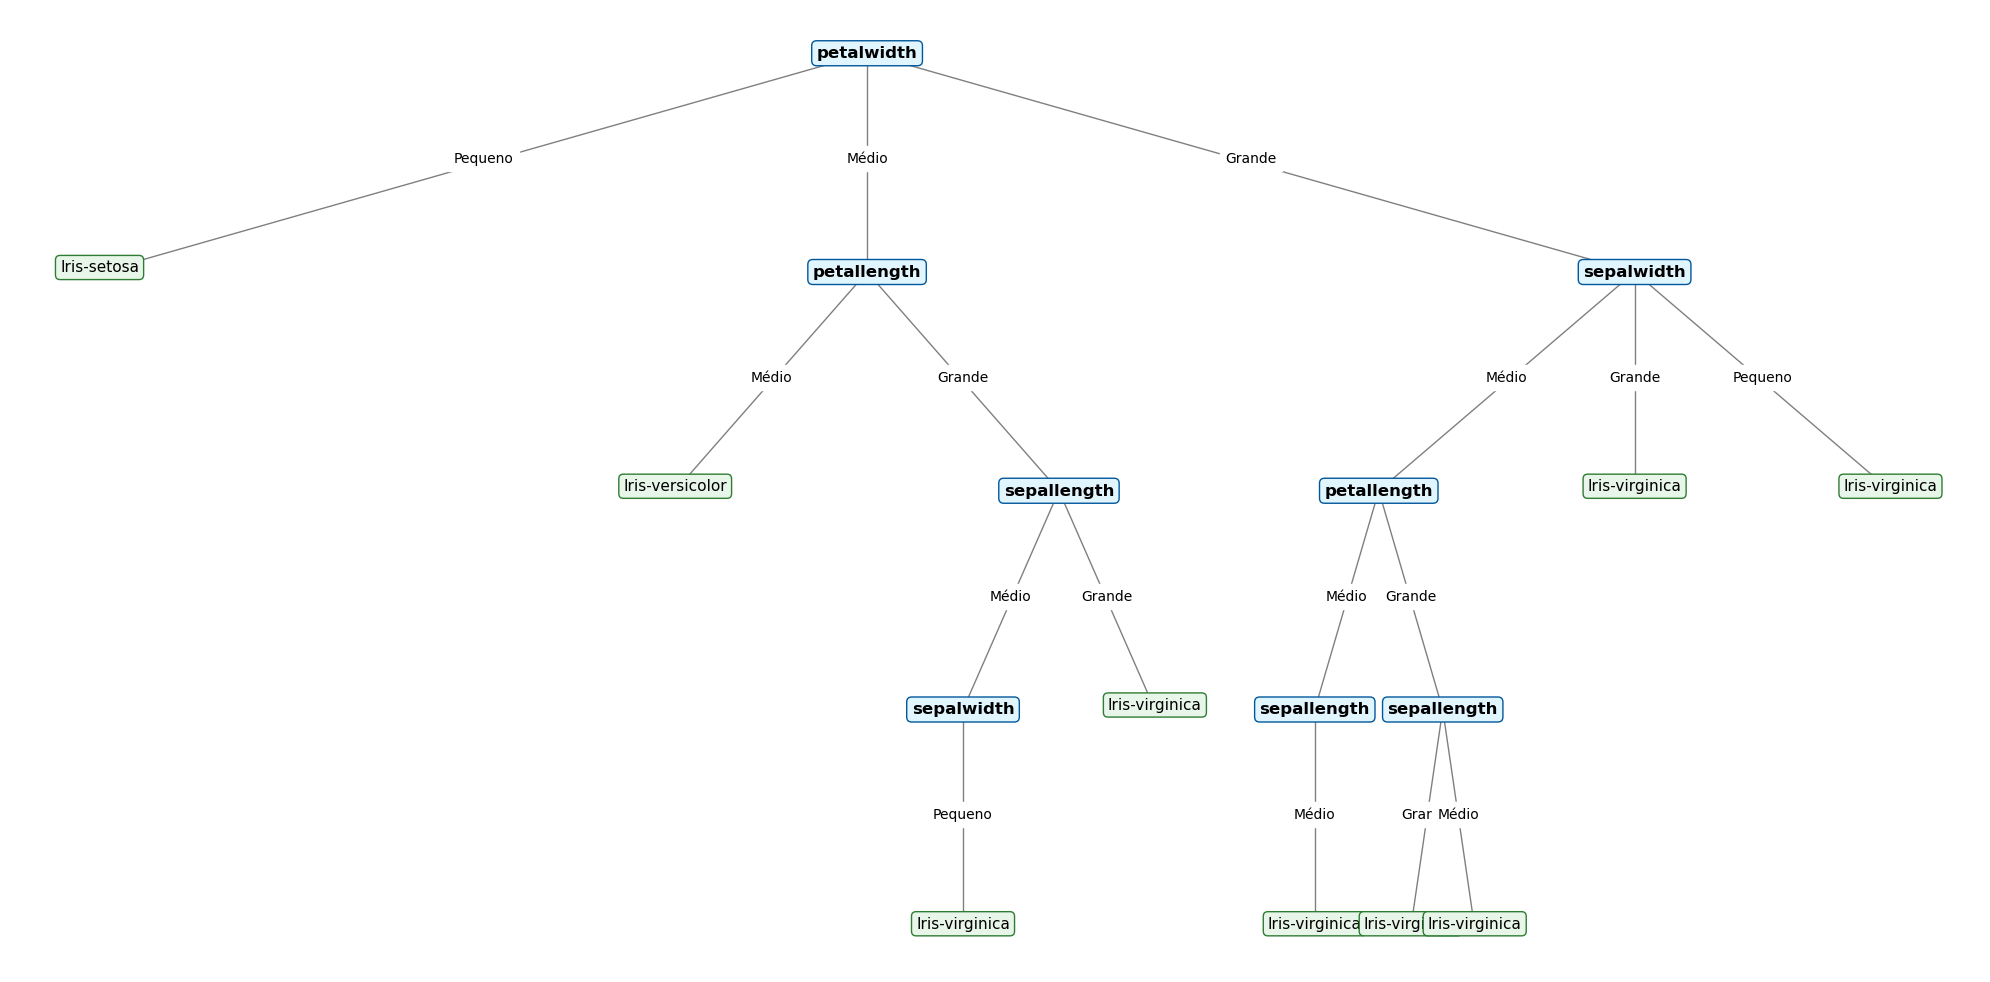

In [18]:
import plot.plot_DT as pp
%matplotlib inline
pp.desenhar(arvore)

&nbsp;A análise que temos a partir do desenho da árvore, é que a variável independente *petalwidth* foi escolhida como a melhor variável para classificar (A), tendo que se esse atributo, assumir a label 'Pequeno', já chegamos em uma folha, e podemos classificar o exemplo como *Iris-setosa*, seguimos por caminhos diferentes se *petalwidth*, assumir a label 'Média' podemos classificar como *Iris-Versicolor*, deixando assim todo o resto a classificar como *Iris-Virginica*, então um novo 'A' é calculado e atribuído para cada nova possibilidade. Sendo assim, percebemos que os dois atributos referentes a pétalas (*petalwidth* e *petalwidth*) são definitivamente mais decisores, e que a partir deles, a árvore começa a 'dar voltas' e olhar todos os outros, e mesmo assim, todos os novos caminhos darão em *Iris-virginica*, o que pode indicar 'outliers' nos dados ou 'overfitting' do modelo.  

&nbsp; Agora que conseguimos visualizar a **Árvore de Decisão** aprendida pelo **ID3**, vamos testar a sua performance em classificar novos exemplos, faremos alguns testes e estudaremos algumas métricas de performance:
1. Testar com os exatos mesmos dados de treino, sem a coluna target;
2. Usar o holdout validation para dividir 70% treino e 30% teste, para testar com exemplos que nunca foram vistos;


In [19]:
#1) Testar com os exatos mesmos dados de treino, sem a coluna target
df_teste = df_disc.drop('class', axis= 1) #teste é o dataset completo sem a coluna target
acertos = 0 #contador de acertos
lista_erros = [] #lista de erros
for i in range(len(df_teste)): #itera sobre todas as linhas do dataset
    exemplo = df_teste.iloc[i].to_dict() #cria um exemplo do index em formato dict
    real = df_disc.iloc[i]['class'] #busca a informação de target real no index i
    predicao = classificador(exemplo,arvore) #classifica o exemplo com a arvore acima 
    print(f'{i+1}) Real: {real} | Predição: {predicao}') #print o real vs oq foi predito
    if real == predicao: #se acertou
        acertos = acertos+1 #conta +1 em acertos
    else: #se errou
        lista_erros.append(i+1) #add o numero da linha do erro na lista de erros + 2 (pq começa em 0 e a primeira linha sao os titulos)
print(f'Acertos: {acertos} de {len(df_disc)}') #imprime acertos
print(f'Acurácia: {100*(acertos/len(df_disc))}%') #imprime acurácia
print(f'Errou nas linhas: {lista_erros}') #imprime lista de erros
    

1) Real: Iris-setosa | Predição: Iris-setosa
2) Real: Iris-setosa | Predição: Iris-setosa
3) Real: Iris-setosa | Predição: Iris-setosa
4) Real: Iris-setosa | Predição: Iris-setosa
5) Real: Iris-setosa | Predição: Iris-setosa
6) Real: Iris-setosa | Predição: Iris-setosa
7) Real: Iris-setosa | Predição: Iris-setosa
8) Real: Iris-setosa | Predição: Iris-setosa
9) Real: Iris-setosa | Predição: Iris-setosa
10) Real: Iris-setosa | Predição: Iris-setosa
11) Real: Iris-setosa | Predição: Iris-setosa
12) Real: Iris-setosa | Predição: Iris-setosa
13) Real: Iris-setosa | Predição: Iris-setosa
14) Real: Iris-setosa | Predição: Iris-setosa
15) Real: Iris-setosa | Predição: Iris-setosa
16) Real: Iris-setosa | Predição: Iris-setosa
17) Real: Iris-setosa | Predição: Iris-setosa
18) Real: Iris-setosa | Predição: Iris-setosa
19) Real: Iris-setosa | Predição: Iris-setosa
20) Real: Iris-setosa | Predição: Iris-setosa
21) Real: Iris-setosa | Predição: Iris-setosa
22) Real: Iris-setosa | Predição: Iris-seto

&nbsp;A partir desse teste, podemos visualizar que a árvore aprendeu de maneira muito satisfatória os exemplos de treino, dos 150 exemplos testados,conquistando uma acurácia de 98%, o classificador errou apenas 3 linhas, são essas:  

71) De X: {'sepallength': 'Médio', 'sepalwidth': 'Médio', 'petallength': 'Médio', 'petalwidth': 'Grande'}  

    De y: Real: Iris-versicolor | Predição: Iris-virginica    

<div align="center">
  <img src="img/dt_iris1.PNG" width="500px">
  <br>
  <sup><b>Figura 5:</b> Análise do Caminho Linha 71 - Árvore ID3 do 'Iris_discretizado'.</sup>
</div>  


78) De X: {'sepallength': 'Grande', 'sepalwidth': 'Médio', 'petallength': 'Grande', 'petalwidth': 'Grande'}  

    De y: Real: Iris-versicolor | Predição: Iris-virginica     

<div align="center">
  <img src="img/dt_iris2.PNG" width="500px">
  <br>
  <sup><b>Figura 6:</b> Análise do Caminho Linha 78 - Árvore ID3 do 'Iris_discretizado'.</sup>
</div>  

84) De X: {'sepallength': 'Médio', 'sepalwidth': 'Pequeno', 'petallength': 'Grande', 'petalwidth': 'Médio'}  

    De y: Real: Iris-versicolor | Predição: Iris-virginica   

<div align="center">
  <img src="img/dt_iris3.PNG" width="500px">
  <br>
  <sup><b>Figura 7:</b> Análise do Caminho Linha 84 - Árvore ID3 do 'Iris_discretizado'.</sup>
</div>  


&nbsp;Isso mostra que a escolha da label, é, nos 3 casos, sempre fiel ao desenho da **Árvore de Decisão**, porém podemos identificar que esses 3 casos não ficam definidos tributos referentes a pétalas (*petalwidth* e **petalwidth**), que são os atributos mais decisores, como apontados anteriormente, para entender o porque da classificação incorreta, vamos analisar o gráfico de dispersão dos dados do dataset, tanto para os atributos de pétalas, como para os atributos de sépalas (tais funções de plotagem podem ser acessadas em 'plot/plot_DT.py'):

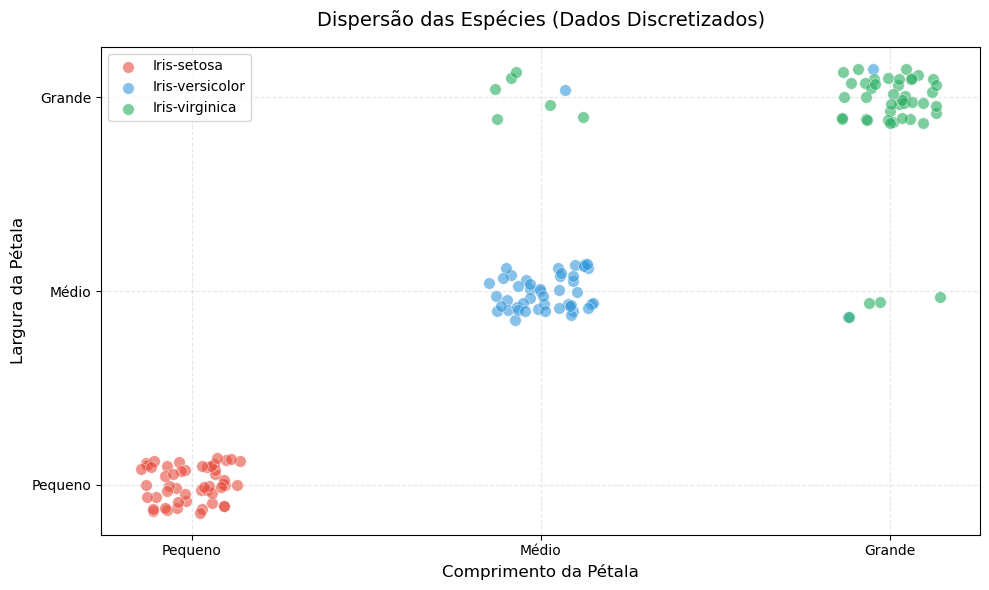

In [20]:
pp.plot_dispersao(df_disc) #Gráfico de Dispersão - Pétalas

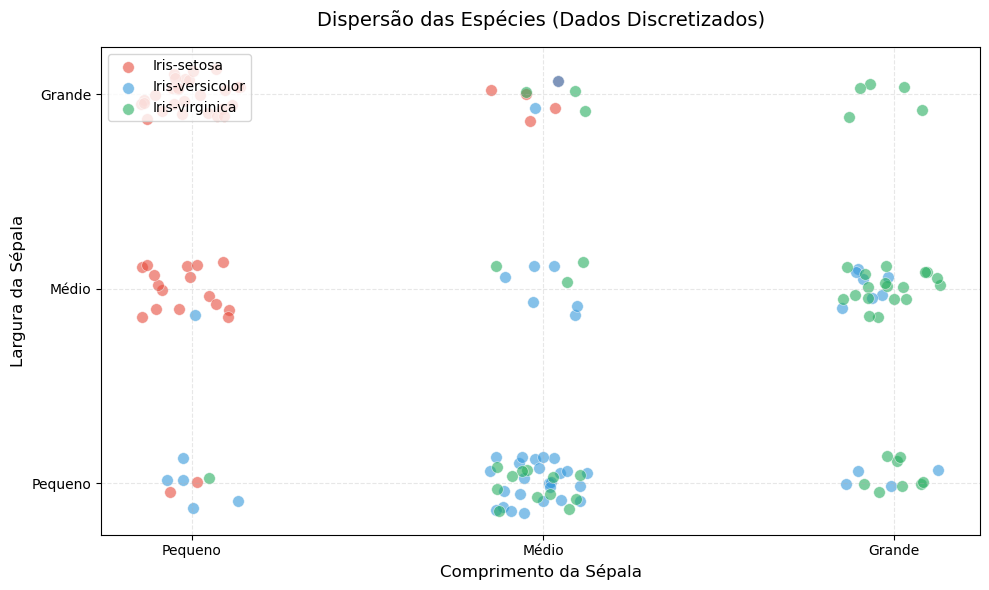

In [21]:
pp.plot_dispersao_sepal(df_disc) #Gráfico de Dispersão - Sépalas

&nbsp;Como já sugerido anteriormente, através desses dois gráficos, percebemos que os atributos de **pétalas**, conseguem separar muito bem para cada classe, exceto a 3 notórios outliers, diferente dos atributos de **sépalas** que não geram uma divisão linear tão clara. Usemos então o **Gráfico de Dispersão - Pétala** para análise mais minuciosa, ao estudar de perto os 3 outliers (pontos azuis - *Iris-Verticolor* ), que se misturam as zonas que mais naturalmente serias classificadas como verde *Iris-Virginica*, percebemos se tratar dos exatos 3 casos que foram previstos de maneira incorreta:
<div align="center">
  <img src="img/scatter_plot_iris_disc_petalas2.PNG" width="500px">
  <br>
  <sup><b>Figura 8:</b> Análise Gráfico de Dispersão - Pétalas do 'Iris_discretizado'.</sup>
</div>  

&nbsp;Com essa visualização cruzada ao desenho da árvore, conseguimos entender exatamente o motivo dos 3 casos terem labels erradas. Para ilustrar tal conclusão, olhemos para o **Gráfico de Decision Boundaries** (tal função de plotagem pode ser vista em 'plt/plot_DT.py'), esse gráfico divide o gráfico em regiões coloridas, onde cada cor representa uma categoria (classe), se um ponto cair na área rosa, o modelo o classifica como Classe A, se cair na verde, Classe B e as fronteiras são os limites onde o modelo muda de opinião sobre o que aquele dado representa:


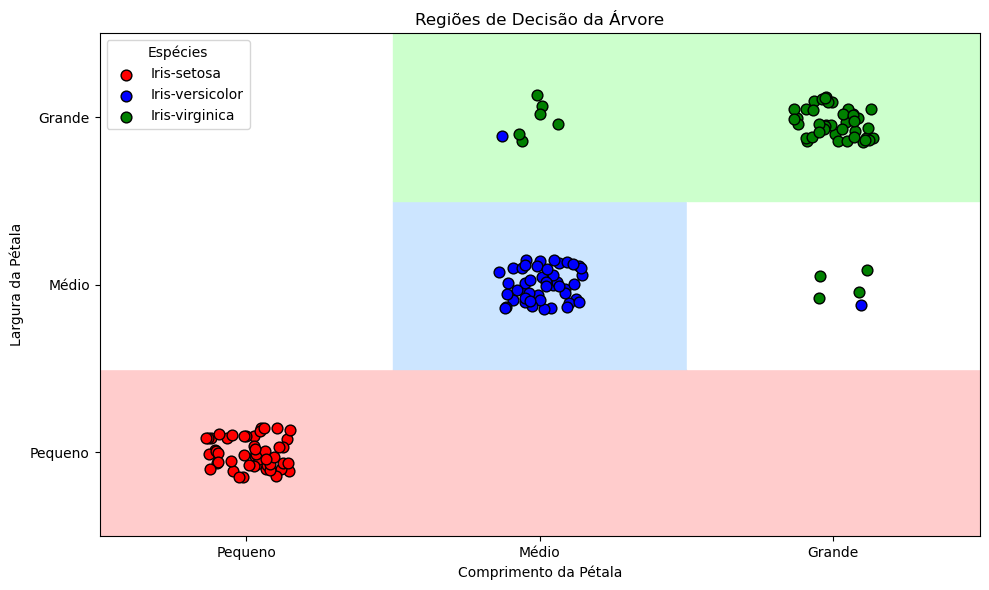

In [22]:
pp.plot_decision_boundaries(df_disc,arvore,classificador)

In [23]:
#2) Usar o holdout validation para dividir 70% treino e 30% teste, para testar com exemplos que nunca foram vistos;
df_shuffle = df_disc.sample(frac=1,random_state=42).reset_index(drop=True) #usa sample para randomizar os dados

df_shuffle.to_csv('../data/processed/iris_shuffle.csv', index=False) #guarda os dados embaralhados em novo arquivo
split_index = int(len(df_shuffle)*0.7) #acha quanto é o equivalente a 70% dentro desse dataset
df_treino = df_shuffle.iloc[:split_index] #define os primeros 70% do dataset para treino
df_test = df_shuffle.iloc[split_index:] #define os ultimos 30% do dataset para teste

print(f"Tamanho total de amostras do dataset: {len(df_shuffle)}")
print(f"Tamanho do dataset de treino (70%): {len(df_treino)}")
print(f"Tamanho do dataset de teste (30%): {len(df_test)}")

Tamanho total de amostras do dataset: 150
Tamanho do dataset de treino (70%): 105
Tamanho do dataset de teste (30%): 45


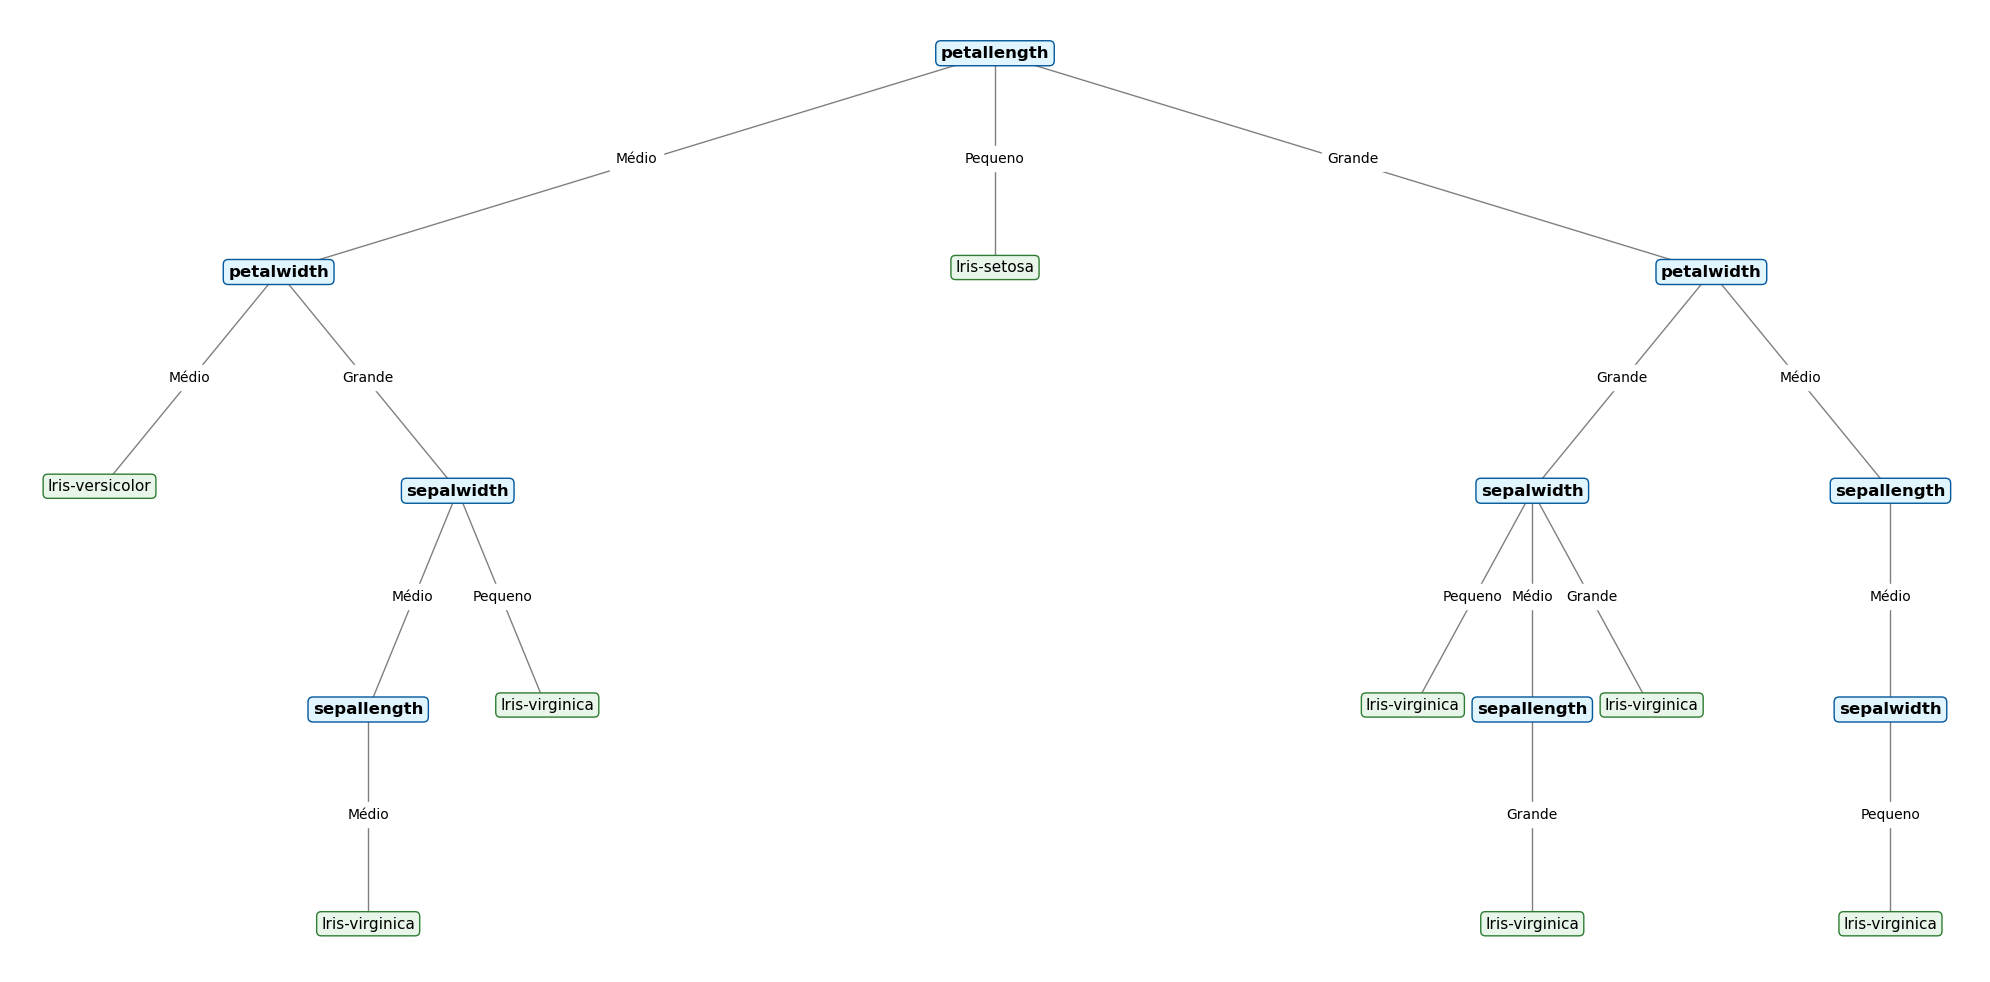

In [24]:
data = df_treino
X = df_treino.drop('class', axis=1)
y = df_treino['class']
arvore2 = my_ID3(df_treino, X,y)
pp.desenhar(arvore2)

In [25]:
df_test_X = df_test.drop('class', axis=1)
df_test_y = df_test['class']

acertos = 0
lista_erros = []
for i in range (len(df_test)):
    exemplo = df_test_X.iloc[i].to_dict()
    real = df_test_y.iloc[i]
    predicao = classificador(exemplo,arvore2)
    print(f"{i+1}) Real: {real} | Predição: {predicao}")
    if real == predicao:
        acertos = acertos +1
    else:
        lista_erros.append(i+1)
print(f"Acertou {acertos} de {len(df_test)}")
print(f"Acurácia: {acertos/len(df_test)}%")
print(f"Errou nos casos: {lista_erros}")

1) Real: Iris-setosa | Predição: Iris-setosa
2) Real: Iris-virginica | Predição: Iris-virginica
3) Real: Iris-virginica | Predição: Iris-virginica
4) Real: Iris-setosa | Predição: Iris-setosa
5) Real: Iris-versicolor | Predição: Iris-versicolor
6) Real: Iris-versicolor | Predição: Iris-versicolor
7) Real: Iris-virginica | Predição: Iris-virginica
8) Real: Iris-versicolor | Predição: Iris-versicolor
9) Real: Iris-virginica | Predição: Iris-virginica
10) Real: Iris-setosa | Predição: Iris-setosa
11) Real: Iris-virginica | Predição: Iris-virginica
12) Real: Iris-versicolor | Predição: Iris-versicolor
13) Real: Iris-virginica | Predição: Iris-virginica
14) Real: Iris-versicolor | Predição: Iris-versicolor
15) Real: Iris-versicolor | Predição: Iris-versicolor
16) Real: Iris-versicolor | Predição: Iris-versicolor
17) Real: Iris-setosa | Predição: Iris-setosa
18) Real: Iris-versicolor | Predição: Iris-versicolor
19) Real: Iris-versicolor | Predição: Iris-versicolor
20) Real: Iris-setosa | Pre

27) Real: Iris-virginica | Predição: Classe Desconhecida
{'sepallength': 'Grande', 'sepalwidth': 'Médio', 'petallength': 'Grande', 'petalwidth': 'Médio'}
39) Real: Iris-virginica | Predição: Classe Desconhecida
{'sepallength': 'Médio', 'sepalwidth': 'Médio', 'petallength': 'Grande', 'petalwidth': 'Grande'}

#### 4.2.2) Datasets - PopOut + MCTS

In [ ]:
import ast
df = pd.read_csv('../data/raw/MCTS_Random_Opening_data.csv')
df.head(5)

df['target'] = df['target'].apply(ast.literal_eval)
df['target'] = df['target'].tolist()


df_0 = df[df['isX'] == 0].drop(columns=['isX'])

df_1 = df[df['isX'] == 1].drop(columns=['isX'])

df_0.to_csv('../data/processed/dataset_isX_0.csv', index=False)
X_O = df_0.drop('target', axis=1)
y_O = df_0['target']

df_1.to_csv('../data/processed/dataset_isX_1.csv', index=False)
X_X = df_1.drop('target', axis=1)
y_X = df_1['target']

tree_MCTS_X = my_ID3(df_1,X_X,y_X)
tree_MCTS_O = my_ID3(df_0, X_O, y_O)



In [51]:
from pprint import pprint

pprint(tree_MCTS_X, indent=4, depth=10)

acertos_X = 0
lista_erros_X = []

df_1_blind = df_1.drop('target', axis=1)

for i in range(len(df_1)):
    exemplo = df_1_blind.iloc[i].to_dict()
    real = df_1.iloc[i]['target']
    predicao = classificador(exemplo,tree_MCTS_X)
    if real == predicao:
        acertos_X = acertos_X +1
    else:
        lista_erros_X.append(i+1)
print(f"Tamanho = {len(df_1)}\nAcertos = {acertos_X}")
print(f'Acuracia = {acertos_X/len(df_1)}')

{   'c31': {   np.int64(-1): {   'c24': {   np.int64(-1): {   'c17': {   np.int64(-1): {   'c33': {   np.int64(-1): {   'c32': {   np.int64(-1): {   'c39': {   np.int64(-1): {   'c22': {   np.int64(0): (   3,
                                                                                                                                                                                                              5),
                                                                                                                                                                                             np.int64(1): (   4,
                                                                                                                                                                                                              2)}},
                                                                                                                                                                